# Entrenamiento CNN 2D Binario (Frijol): T4 vs Otros

Este notebook entrena una CNN 2D con tensores multiespectrales `H x W x 10` para clasificar **T4** frente a **otros tratamientos (T1,T2,T3)**.

## 0. Librerias y semilla

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

tf.keras.utils.set_random_seed(42)

## 1. Configuracion

In [ ]:

manifest_path = "datasets/object_split_frijol_tensors.csv"

# Todos los tensores son ya 128x128x10
IMG_HEIGHT   = 128
IMG_WIDTH    = 128
NUM_CHANNELS = 10
BATCH_SIZE   = 32 

# Entrenamiento
EPOCHS        = 100
LEARNING_RATE = 3e-4

# Normalización: zscore_masked
NORMALIZATION_MODE = "zscore_masked"

# Regularización
L2_LAMBDA      = 5e-5
DROPOUT_BLOCK1 = 0.10
DROPOUT_BLOCK2 = 0.20
DROPOUT_BLOCK3 = 0.25
DROPOUT_DENSE  = 0.30

print("Configuración lista para T4 vs Otros")
print(f"- EPOCHS={EPOCHS}, LR={LEARNING_RATE}, BATCH_SIZE={BATCH_SIZE}")
print(f"- NORMALIZATION_MODE={NORMALIZATION_MODE}")
print(f"- L2_LAMBDA={L2_LAMBDA}")


Configuración lista para T4 vs Otros
- EPOCHS=100, LR=0.0003, BATCH_SIZE=32
- NORMALIZATION_MODE=zscore_masked
- L2_LAMBDA=5e-05


## 2. Carga de manifest y etiquetas binarias

In [3]:

if not os.path.isfile(manifest_path):
    raise FileNotFoundError(f"No existe manifest: {manifest_path}")

manifest_df = pd.read_csv(manifest_path).copy()
required_cols = {"object_id", "split", "tensor_path", "tratamiento", "plant_id"}
missing_cols = required_cols - set(manifest_df.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas en manifest: {sorted(missing_cols)}")

manifest_df["tensor_path"] = manifest_df["tensor_path"].astype(str)
manifest_df["object_id"]   = manifest_df["object_id"].astype(str)
manifest_df["plant_id"]    = manifest_df["plant_id"].astype(str)
manifest_df["tratamiento"] = manifest_df["tratamiento"].astype(int)

# Etiqueta binaria: T4 = 1 (positivo / deficiencia severa), Otros = 0
manifest_df["label_name"] = np.where(manifest_df["tratamiento"] == 4, "T4", "Otros")
manifest_df["label"]      = np.where(manifest_df["tratamiento"] == 4, 1, 0).astype(int)

manifest_df["exists"] = manifest_df["tensor_path"].map(os.path.isfile)
n_missing = int((~manifest_df["exists"]).sum())
if n_missing > 0:
    display(manifest_df.loc[~manifest_df["exists"], ["object_id", "tensor_path"]].head(10))
    raise ValueError(f"Hay {n_missing} rutas de tensor no existentes.")

print("Registros totales:", len(manifest_df))
print("\nConteo binario por split:")
print(manifest_df.groupby(["split", "label_name"]).size().unstack(fill_value=0).to_string())


Registros totales: 383

Conteo binario por split:
label_name  Otros  T4
split                
test           45  15
train         201  66
val            42  14


## 3. Split train/val/test y validacion

In [ ]:
# Usar los splits definidos en el manifest
train_df = manifest_df[manifest_df["split"] == "train"].copy()
val_df   = manifest_df[manifest_df["split"] == "val"].copy()
test_df  = manifest_df[manifest_df["split"] == "test"].copy()

for df, name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    if df.empty:
        raise ValueError(f"Split '{name}' vacío en manifest.")

train_paths  = train_df["tensor_path"].values
train_labels = train_df["label"].values
val_paths    = val_df["tensor_path"].values
val_labels   = val_df["label"].values
test_paths   = test_df["tensor_path"].values
test_labels  = test_df["label"].values

# validación: ningún objeto puede aparecer en más de un split
train_objects = set(train_df["object_id"].unique())
val_objects   = set(val_df["object_id"].unique())
test_objects  = set(test_df["object_id"].unique())

if train_objects & test_objects:
    raise ValueError(f"CRUCE train-test: {len(train_objects & test_objects)} objetos.")
if val_objects & test_objects:
    raise ValueError(f"CRUCE val-test: {len(val_objects & test_objects)} objetos.")

print(f"Train: {len(train_paths):,} | Val: {len(val_paths):,} | Test: {len(test_paths):,}")
print("\nDistribución binaria:")
for name, labels in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    t4 = int((labels == 1).sum()); otros = int((labels == 0).sum())
    print(f"  {name}: T4={t4}, Otros={otros}, ratio={otros/t4:.2f}×")
print("\nVALIDACIÓN ANTI-CRUCE: APROBADA")


Train: 267 | Val: 56 | Test: 60

Distribución binaria:
  train: T4=66, Otros=201, ratio=3.05×
  val: T4=14, Otros=42, ratio=3.00×
  test: T4=15, Otros=45, ratio=3.00×

VALIDACIÓN ANTI-CRUCE: APROBADA


## 4. Pipeline tf.data

In [ ]:

def _read_npy_tensor(path_bytes):
    path = path_bytes.decode("utf-8")
    arr = np.load(path).astype(np.float32)
    if arr.ndim != 3:
        raise ValueError(f"Tensor inválido en {path}. shape={arr.shape}")
    return arr


def load_and_preprocess_tensor(path, label):
    tensor = tf.numpy_function(_read_npy_tensor, [path], tf.float32)
    # Todos los tensores son ya 128x128x10
    tensor.set_shape([IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS])

    # Sanitización: NaN/Inf -> 0
    tensor = tf.where(tf.math.is_finite(tensor), tensor, tf.zeros_like(tensor))

    # zscore_masked: z-score solo sobre píxeles de hoja (no-zero)
    mask   = tf.cast(tf.reduce_any(tensor != 0, axis=-1, keepdims=True), tf.float32)
    n_leaf = tf.maximum(tf.reduce_sum(mask), 1.0)
    mean   = tf.reduce_sum(tensor * mask, axis=[0, 1], keepdims=True) / n_leaf
    diff   = (tensor - mean) * mask
    var    = tf.reduce_sum(tf.square(diff), axis=[0, 1], keepdims=True) / n_leaf
    std    = tf.sqrt(var + 1e-6)
    tensor = diff / std

    return tensor, tf.cast(label, tf.float32)


def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=123, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess_tensor, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

rng = np.random.default_rng(42)
t4_mask = train_labels == 1
otros_mask = train_labels == 0
t4_paths_raw, t4_labels_raw = train_paths[t4_mask], train_labels[t4_mask]
otros_paths_raw, otros_labels_raw = train_paths[otros_mask], train_labels[otros_mask]

n_target = len(otros_paths_raw)
t4_oversamp = rng.choice(len(t4_paths_raw), size=n_target, replace=True)
train_paths_bal = np.concatenate([otros_paths_raw, t4_paths_raw[t4_oversamp]])
train_labels_bal = np.concatenate([otros_labels_raw, t4_labels_raw[t4_oversamp]])
perm = rng.permutation(len(train_paths_bal))
train_paths_bal = train_paths_bal[perm]
train_labels_bal = train_labels_bal[perm]

train_ds = make_dataset(train_paths_bal, train_labels_bal, training=True)
# train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)

# Verificación rápida
for x_batch, y_batch in train_ds.take(1):
    print("Rango X: min=", float(tf.reduce_min(x_batch)), " max=", float(tf.reduce_max(x_batch)))


Rango X: min= -7.387343883514404  max= 3.966745615005493


## 5. Modelo CNN 2D binario

In [ ]:

reg = tf.keras.regularizers.l2(L2_LAMBDA)

# Aumentación geométrica
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
], name="data_augmentation")

inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

x = data_augmentation(inputs)

# Mezcla espectral: combinaciones de bandas aprendidas
x = layers.Conv2D(NUM_CHANNELS * 2, 1, padding="same", activation="elu",
                  kernel_initializer="he_normal",
                  kernel_regularizer=reg, name="spectral_mixing")(x)

# Bloque 1: 128x128 -> 64x64
x = layers.SeparableConv2D(32, 3, padding="same", activation="elu",
                           depthwise_initializer="he_normal",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK1)(x)

# Bloque 2: 64x64 -> 32x32
x = layers.SeparableConv2D(64, 3, padding="same", activation="elu",
                           depthwise_initializer="he_normal",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK2)(x)

# Bloque 3: 32x32 -> 16x16
x = layers.SeparableConv2D(128, 3, padding="same", activation="elu",
                           depthwise_initializer="he_normal",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK3)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="elu", 
                 kernel_initializer="he_normal",
                 kernel_regularizer=reg)(x)
x = layers.Dropout(DROPOUT_DENSE)(x)
outputs = layers.Dense(1)(x) 

model = tf.keras.Model(inputs, outputs, name="frijol_binary_spectral_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

model.summary()


Model: "frijol_binary_spectral_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_mixing (Conv2D)        │ (None, 128, 128, 20)   │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 32)   │           852 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,689 (80.82 KB)

 Trainable params: 20,689 (80.82 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento

In [ ]:
os.makedirs("models/frijol", exist_ok=True)
os.makedirs("results", exist_ok=True)

best_model_path = "models/frijol/frijol_model_cnn_multispectral_tensor_t4_vs_otros_best.keras"
history_csv     = "results/training_history_frijol_t4_vs_otros.csv"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=20,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(history_csv),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    # class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nCheckpoint guardado en: {best_model_path}")
print(f"Historial en: {history_csv}")


Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.4543 - auc: 0.4447 - loss: 0.7093
Epoch 1: val_auc improved from None to 0.44048, saving model to models/frijol/frijol_model_cnn_multispectral_tensor_t4_vs_otros_best.keras

Epoch 1: finished saving model to models/frijol/frijol_model_cnn_multispectral_tensor_t4_vs_otros_best.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.5000 - auc: 0.4349 - loss: 0.7100 - val_accuracy: 0.7500 - val_auc: 0.4405 - val_loss: 0.7181 - learning_rate: 3.0000e-04
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.5007 - auc: 0.5744 - loss: 0.7086
Epoch 2: val_auc improved from 0.44048 to 0.50000, saving model to models/frijol/frijol_model_cnn_multispectral_tensor_t4_vs_otros_best.keras

Epoch 2: finished saving model to models/frijol/frijol_model_cnn_multispectral_tensor_t4_vs_otros_best.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 306ms/step - accuracy: 0.5000 - auc: 0.5326 - loss: 0.7086 - val_accuracy: 0.7500 - val_au

## 7. Evaluacion (Val/Test)

In [ ]:
# El modelo en memoria ya tiene los mejores pesos (restore_best_weights=True)
trained_model = model

def predict_binary(ds, model, threshold=0.5):
    y_true, y_prob = [], []
    for xb, yb in ds:
        logits = model(xb, training=False,).numpy().reshape(-1)
        prob = tf.sigmoid(logits).numpy()
        y_true.extend(yb.numpy().astype(int).tolist())
        y_prob.extend(prob.tolist())
    y_true = np.array(y_true, dtype=int)
    y_prob = np.array(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)
    return y_true, y_pred, y_prob


print("Prediciendo val...")
y_val_true,  y_val_pred,  y_val_prob  = predict_binary(val_ds,  trained_model)
print("Prediciendo test...")
y_test_true, y_test_pred, y_test_prob = predict_binary(test_ds, trained_model)

metrics_rows = []
for split, yt, yp, yprob in [
    ("val",  y_val_true,  y_val_pred,  y_val_prob),
    ("test", y_test_true, y_test_pred, y_test_prob),
]:
    metrics_rows.append({
        "split":     split,
        "acc":       accuracy_score(yt, yp),
        "precision": precision_score(yt, yp, zero_division=0),
        "recall":    recall_score(yt, yp, zero_division=0),
        "f1":        f1_score(yt, yp, zero_division=0),
        "auc":       roc_auc_score(yt, yprob),
        "kappa":     cohen_kappa_score(yt, yp),
    })

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.round(4))

print("\nReporte de clasificación (Test):")
print(classification_report(y_test_true, y_test_pred,
                             target_names=["Otros", "T4"], zero_division=0))


Prediciendo val...
Prediciendo test...


,split,acc,precision,recall,f1,auc,kappa
0,val,0.5179,0.3243,0.8571,0.4706,0.6718,0.1692
1,test,0.5833,0.3684,0.9333,0.5283,0.7496,0.2647



Reporte de clasificación (Test):
              precision    recall  f1-score   support

       Otros       0.95      0.47      0.63        45
          T4       0.37      0.93      0.53        15

    accuracy                           0.58        60
   macro avg       0.66      0.70      0.58        60
weighted avg       0.81      0.58      0.60        60



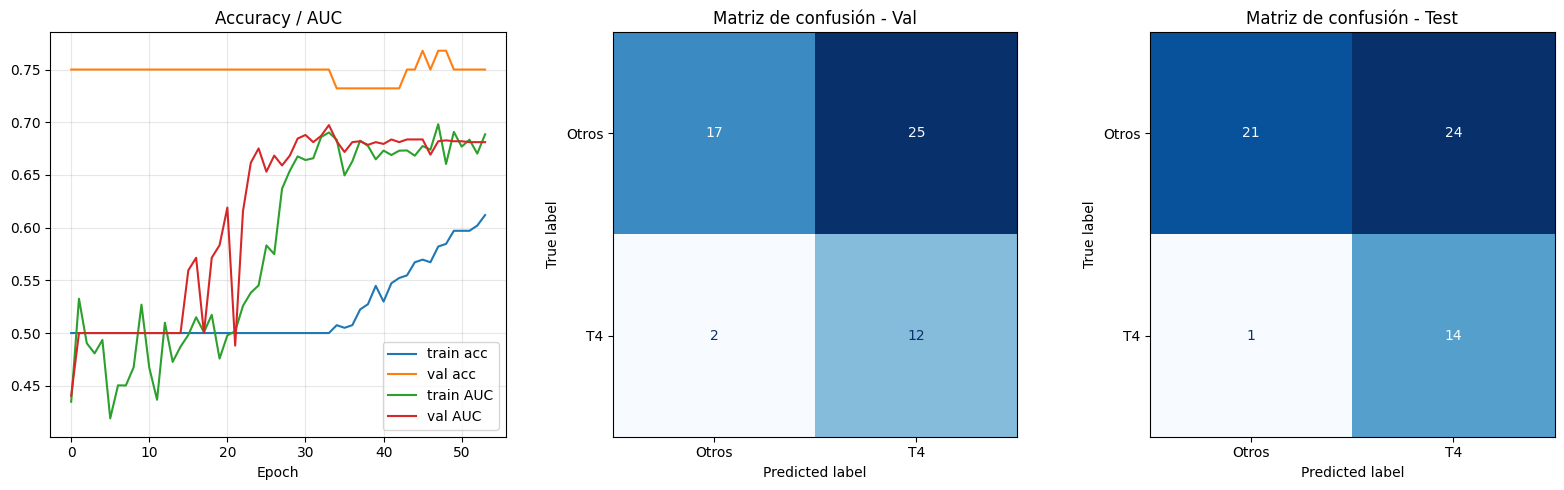

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Curvas de entrenamiento
axes[0].plot(history.history["accuracy"],     label="train acc")
axes[0].plot(history.history["val_accuracy"], label="val acc")
axes[0].plot(history.history["auc"],          label="train AUC")
axes[0].plot(history.history["val_auc"],      label="val AUC")
axes[0].set_title("Accuracy / AUC")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm_val  = confusion_matrix(y_val_true,  y_val_pred)
cm_test = confusion_matrix(y_test_true, y_test_pred)

ConfusionMatrixDisplay(cm_val,  display_labels=["Otros", "T4"]).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Matriz de confusión - Val")
axes[1].grid(False)

ConfusionMatrixDisplay(cm_test, display_labels=["Otros", "T4"]).plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("Matriz de confusión - Test")
axes[2].grid(False)

plt.tight_layout()
plt.show()


## 8. Grad-CAM: visualización de zonas de activación

Grad-CAM muestra qué zonas espaciales de la hoja activaron más la predicción **T4** (deficiencia severa de P).

- **Activaciones en bordes y extremos de hoja** → el modelo detecta los síntomas periféricos de deficiencia de P (coloración rojiza/clorótica en márgenes).
- **Activaciones difusas en limbo central** → el modelo usa textura espectral global; menos específico biológicamente.


In [13]:

def _get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, (tf.keras.layers.SeparableConv2D, tf.keras.layers.Conv2D)):
            return layer.name
    raise ValueError("No se encontró capa convolucional en el modelo.")


def gradcam_heatmap_binary(img_array, model, conv_layer_name):
    """
    Grad-CAM para clasificación binaria con logit de salida único.
    Activa el gradiente respecto al único logit de salida (sin argmax).
    """
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(conv_layer_name).output, model.output],
    )
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_out, logit = grad_model(img_tensor, training=False)
        score = logit[0, 0]  # único logit; positivo = T4

    grads  = tape.gradient(score, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam    = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])
    cam    = tf.nn.relu(cam).numpy()
    if cam.max() > 0:
        cam = cam / cam.max()
    prob = float(tf.sigmoid(logit[0, 0]).numpy())
    return cam, prob


def overlay_heatmap(img_rgb, heatmap, alpha=0.50):
    H, W = img_rgb.shape[:2]
    cam_resized = tf.image.resize(
        heatmap[..., np.newaxis], [H, W], method="bilinear"
    ).numpy().squeeze()
    colored = plt.cm.jet(cam_resized)[:, :, :3]
    return np.clip((1 - alpha) * img_rgb + alpha * colored, 0, 1)


last_conv_layer = _get_last_conv_layer_name(trained_model)
print(f"Capa objetivo Grad-CAM: '{last_conv_layer}'")

# En Keras 3 algunos layers ya no exponen .output_shape; usar layer.output.shape es más robusto
target_layer = trained_model.get_layer(last_conv_layer)
activation_shape = getattr(target_layer, "output_shape", None)
if activation_shape is None:
    activation_shape = tuple(target_layer.output.shape)
print(f"Shape de activaciones: {activation_shape}")


Capa objetivo Grad-CAM: 'separable_conv2d_2'
Shape de activaciones: (None, 32, 32, 128)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9652\439659462.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 1])


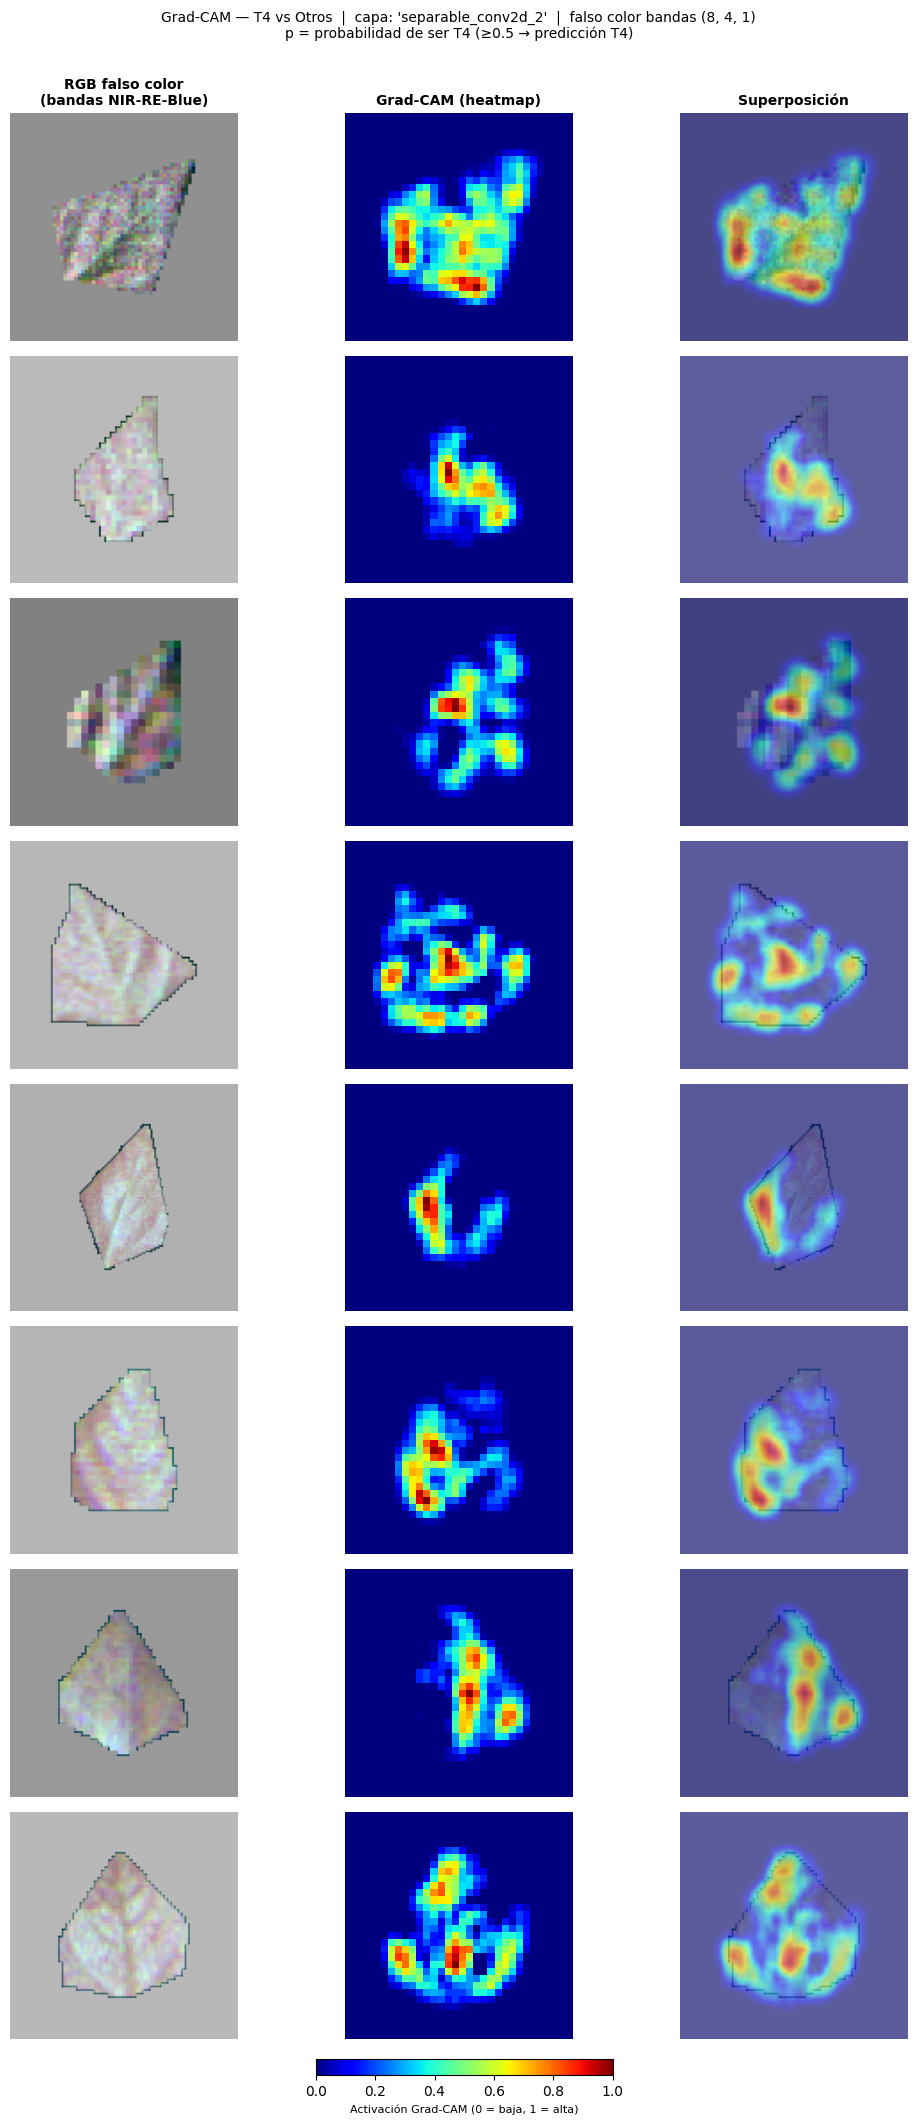

In [14]:

# Parámetros de visualización
N_PER_CLASS   = 4      # muestras de test por clase (T4 y Otros)
ALPHA_OVERLAY = 0.50
BANDS_RGB     = (8, 4, 1)  # falso color: NIR, Red-Edge, Blue

# Recolectar tensores de test por clase binaria
samples_by_label = {0: [], 1: []}
for xb, yb in test_ds:
    for xi, yi in zip(xb.numpy(), yb.numpy()):
        lbl = int(yi)
        if len(samples_by_label[lbl]) < N_PER_CLASS:
            samples_by_label[lbl].append(xi)
    if all(len(v) >= N_PER_CLASS for v in samples_by_label.values()):
        break

label_display = {0: "Otros", 1: "T4"}
total_rows = 2 * N_PER_CLASS
fig, axes = plt.subplots(total_rows, 3, figsize=(11, 2.6 * total_rows))

col_titles = ["RGB falso color\n(bandas NIR-RE-Blue)", "Grad-CAM (heatmap)", "Superposición"]
for col, ct in enumerate(col_titles):
    axes[0, col].set_title(ct, fontsize=10, fontweight="bold")

row = 0
for lbl in [0, 1]:
    for sample_i, tensor in enumerate(samples_by_label[lbl][:N_PER_CLASS]):
        img_input = tensor[np.newaxis]

        cam, prob = gradcam_heatmap_binary(img_input, trained_model, last_conv_layer)
        pred_lbl  = 1 if prob >= 0.5 else 0
        is_correct = pred_lbl == lbl
        result_str = f"✓ p={prob:.2f}" if is_correct else f"✗ p={prob:.2f}"

        b0, b1, b2 = BANDS_RGB
        rgb = np.stack([tensor[:, :, b0], tensor[:, :, b1], tensor[:, :, b2]], axis=-1)
        rmin, rmax = rgb.min(), rgb.max()
        rgb_norm = np.clip((rgb - rmin) / (rmax - rmin + 1e-6), 0, 1)

        overlay = overlay_heatmap(rgb_norm, cam, alpha=ALPHA_OVERLAY)

        axes[row, 0].imshow(rgb_norm)
        axes[row, 0].set_ylabel(f"{label_display[lbl]}  #{sample_i + 1}\n({result_str})",
                                fontsize=8, labelpad=4)
        axes[row, 0].axis("off")

        im = axes[row, 1].imshow(cam, cmap="jet", vmin=0, vmax=1)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay)
        axes[row, 2].axis("off")

        row += 1

cbar_ax = fig.add_axes([0.37, 0.01, 0.27, 0.008])
plt.colorbar(im, cax=cbar_ax, orientation="horizontal").set_label(
    "Activación Grad-CAM (0 = baja, 1 = alta)", fontsize=8
)
plt.suptitle(
    f"Grad-CAM — T4 vs Otros  |  capa: '{last_conv_layer}'  |  "
    f"falso color bandas {BANDS_RGB}\n"
    "p = probabilidad de ser T4 (≥0.5 → predicción T4)",
    fontsize=10, y=1.003,
)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()


## 9. Guardado de artefactos

In [15]:

final_model_path = "models/frijol/frijol_model_cnn_multispectral_tensor_t4_vs_otros_final.keras"
metrics_path     = "results/training_results_frijol_t4_vs_otros.csv"

trained_model.save(final_model_path)
metrics_df.to_csv(metrics_path, index=False)

print(f"Modelo final:      {final_model_path}")
print(f"Mejor checkpoint:  {best_model_path}")
print(f"Historial:         {history_csv}")
print(f"Métricas:          {metrics_path}")


Modelo final:      models/frijol/frijol_model_cnn_multispectral_tensor_t4_vs_otros_final.keras
Mejor checkpoint:  models/frijol/frijol_model_cnn_multispectral_tensor_t4_vs_otros_best.keras
Historial:         results/training_history_frijol_t4_vs_otros.csv
Métricas:          results/training_results_frijol_t4_vs_otros.csv
